In [1]:
from sp500 import load_sp500_prices_df, compute_covariance, compute_log_returns, START_DATE, END_DATE, solve_sp500_fw_homotopy, solve_sp500_greedy
from sp500_plots import plot_corr_heatmap, plot_selection_heatmap, plot_objective_comparison, plot_submatrix_comparison

# SAVE_PATH = 

prices_df = load_sp500_prices_df(start=START_DATE, end=END_DATE)
stock_names = prices_df.columns.tolist()

log_return_matrix = compute_log_returns(prices_df)
A = compute_covariance(log_return_matrix)


/Users/nautilus/gridfw/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cached Kaggle data (12 days old).
Loading cached prices (0 days old)...
X: (20, 484) | A: (484, 484)

Running FW-Homotopy (k=50, p=484)...
[FWHomotopy] p=484, k=50, steps=800, n_mc=100, alpha=0.01
['ABT', 'AKAM', 'ALB', 'AMD', 'ANET', 'APA', 'APH', 'APTV', 'AXON', 'BLDR', 'CEG', 'CHTR', 'CNC', 'COF', 'CSGP', 'CZR', 'DECK', 'ENPH', 'FSLR', 'GE', 'GLW', 'HUM', 'INTC', 'INTU', 'IT', 'JBL', 'KLAC', 'LRCX', 'LUV', 'LVS', 'MCHP', 'META', 'MRNA', 'MU', 'NCLH', 'NEM', 'ON', 'ORCL', 'RCL', 'SLB', 'SMCI', 'STX', 'SWKS', 'SYF', 'TFX', 'UNH', 'URI', 'VLO', 'VST', 'WDC']

Running Greedy...
['ACGL', 'ACN', 'ADM', 'ALB', 'AMD', 'AMP', 'ANET', 'APA', 'APH', 'APTV', 'AXON', 'BLDR', 'CEG', 'DECK', 'DRI', 'ENPH', 'EQR', 'EQT', 'EXPE', 'FFIV', 'GE', 'GPN', 'HUM', 'INTC', 'INTU', 'IT', 'JNJ', 'KLAC', 'LUV', 'MRNA', 'MU', 'NTAP', 'ODFL', 'ORCL', 'PEP', 'PSX', 'RCL', 'REGN', 'ROK', 'SMCI', 'SWKS', 'SYF', 'TER', 'TFX', 'TPL', 'TSLA', 'TXN', 'UNH', 'VLO', 'WDC']
Using cached Kaggle data (12 days old).
Lo

# Plot Correlation Matrix Heatmap
Plot a heat map to see some patterns

/Users/nautilus/gridfw/examples/market/sp500_plots.py:20: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, method="ward")


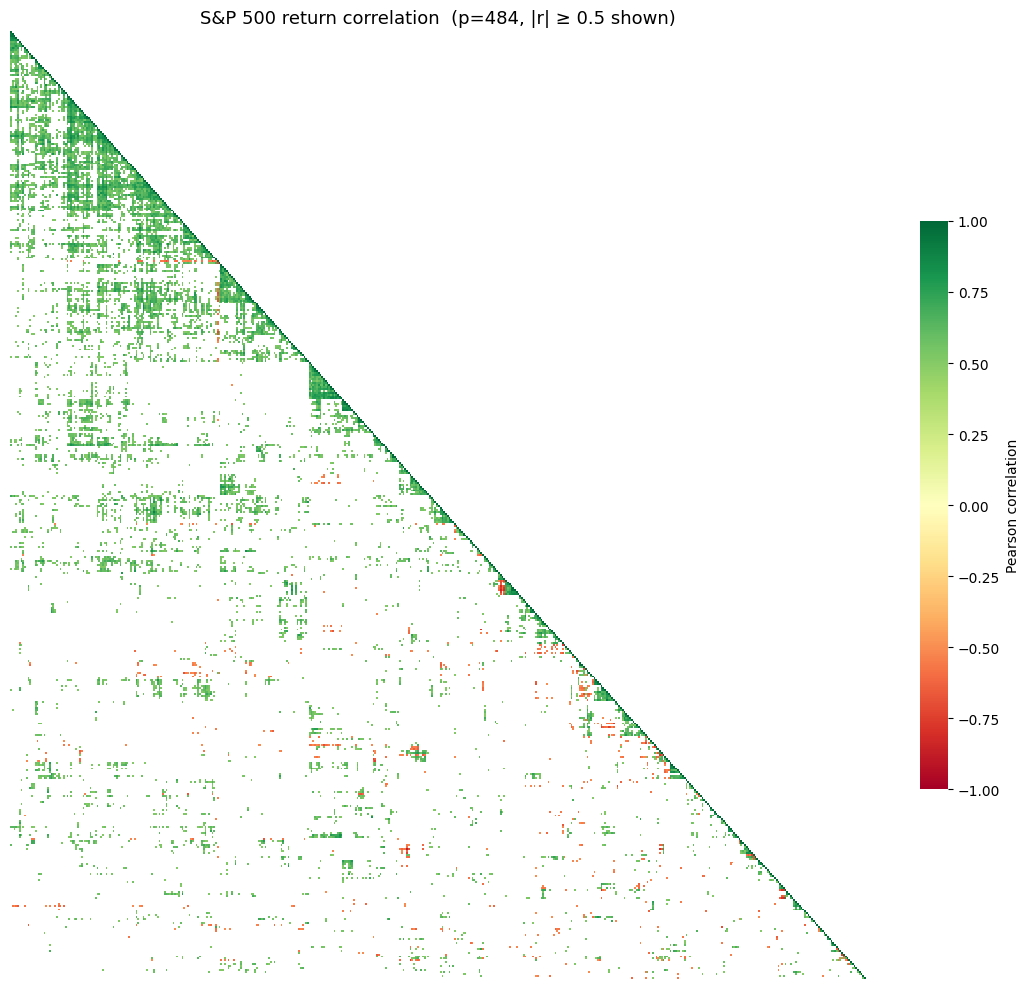

X: (20, 484) | A: (484, 484)


In [2]:

plot_corr_heatmap(log_return_matrix, threshold=0.5)
print(f"X: {log_return_matrix.shape} | A: {A.shape}")


Running FW-Homotopy (k=50, p=484)...
[FWHomotopy] p=484, k=50, steps=800, n_mc=100, alpha=0.01
['ABT', 'AKAM', 'ALB', 'AMD', 'ANET', 'APA', 'APH', 'APTV', 'AXON', 'BLDR', 'CEG', 'CHTR', 'COF', 'CSGP', 'CZR', 'DECK', 'ELV', 'ENPH', 'FSLR', 'GE', 'GLW', 'HUM', 'INTC', 'INTU', 'IT', 'JBL', 'KLAC', 'LRCX', 'LUV', 'LVS', 'LYB', 'MCHP', 'MRNA', 'MU', 'NCLH', 'NOW', 'ORCL', 'RCL', 'SMCI', 'STX', 'SWKS', 'SYF', 'TER', 'TFX', 'TSLA', 'UNH', 'URI', 'VLO', 'VST', 'WDC']

Running Greedy...
['ACGL', 'ACN', 'ADM', 'ALB', 'AMD', 'AMP', 'ANET', 'APA', 'APH', 'APTV', 'AXON', 'BLDR', 'CEG', 'DECK', 'DRI', 'ENPH', 'EQR', 'EQT', 'EXPE', 'FFIV', 'GE', 'GPN', 'HUM', 'INTC', 'INTU', 'IT', 'JNJ', 'KLAC', 'LUV', 'MRNA', 'MU', 'NTAP', 'ODFL', 'ORCL', 'PEP', 'PSX', 'RCL', 'REGN', 'ROK', 'SMCI', 'SWKS', 'SYF', 'TER', 'TFX', 'TPL', 'TSLA', 'TXN', 'UNH', 'VLO', 'WDC']


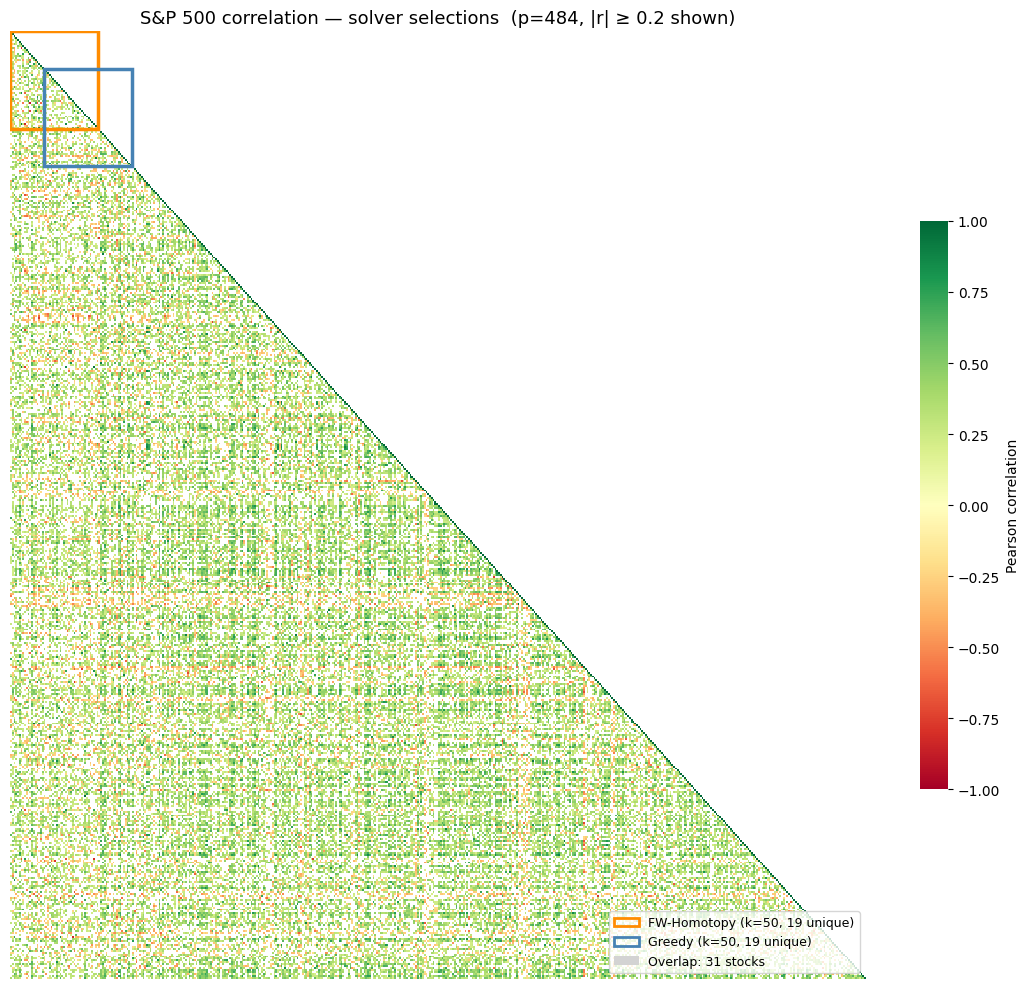

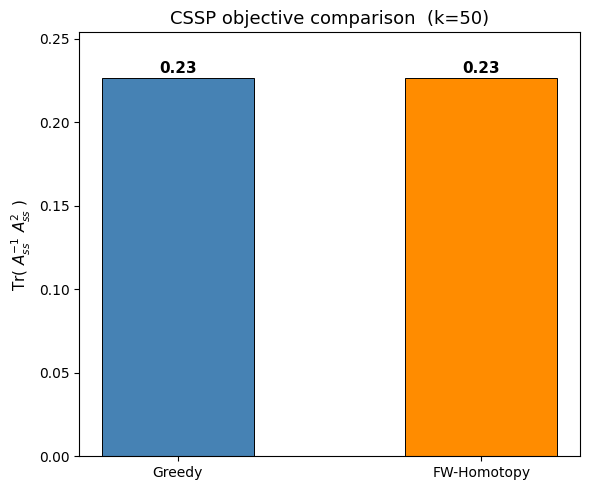

/Users/nautilus/gridfw/examples/market/sp500_plots.py:243: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  order = leaves_list(linkage(dist, method="ward"))
/Users/nautilus/gridfw/examples/market/sp500_plots.py:243: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  order = leaves_list(linkage(dist, method="ward"))


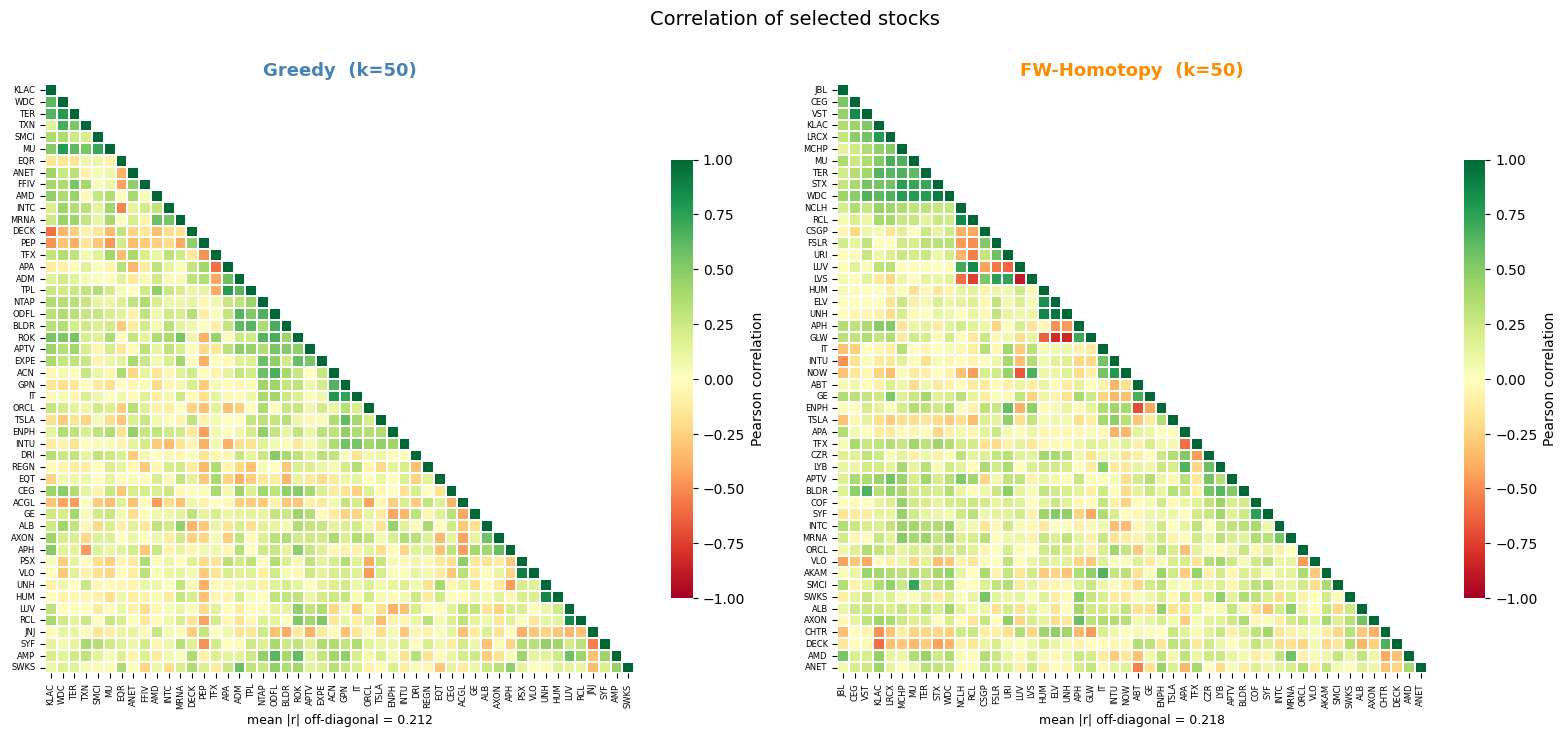

In [3]:
k= 50
fw_indices = solve_sp500_fw_homotopy(A=A,k=k, stock_names=stock_names )
greedy_indices = solve_sp500_greedy(A=A, k=k, stock_names=stock_names)

plot_selection_heatmap(log_return_matrix, fw_indices, greedy_indices)
plot_objective_comparison(A, fw_indices, greedy_indices)
plot_submatrix_comparison(log_return_matrix, fw_indices, greedy_indices, stock_names)